In [ ]:
import sys,os
sys.path.append('../../')
os.environ["JAX_PLATFORMS"] = "cpu"
import matplotlib.pyplot as plt
import numpy as np
from utils import makefolder,get_acronym,depths,reduce_list_half_preserve_extremes

from geometry import * 

eps = 1E-7
rcpsize = 12
plt.rcParams['xtick.labelsize']= rcpsize
plt.rcParams['ytick.labelsize']=rcpsize
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = rcpsize
plt.rcParams.update({'figure.autolayout': True})
#colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['ggplot']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8-dark-palette']['axes.prop_cycle'].by_key()['color']
from cycler import cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
# print(plt.rcParams.keys())
#np.set_printoptions(precision=None)
markers = ['p','o','h','^','s','*']
_linestyles = ['-','--','dotted']
plot_id = 0

In [ ]:
modelA = 'deepseek'
# modelA = 'llama'
modelB = modelA
language_pairs = [('english','spanish'),
                  ]
aux_A = 'source'
aux_B = 'target'

batch_shuffle = 0
min_token_length = 7
n_files = 20
batch_size = 100
Ns = batch_size*n_files
n_tokens_list = [7]
avg = 0
Nbits_list = [0]

idx = None
match_vars = ['matching','mismatching']
random_centers_list = [-1,0,1]

In [ ]:
fig,ax = plt.subplots(1)

for random_centers_id,random_centers in enumerate(random_centers_list):
  for match_id,match_var in enumerate(match_vars):
    if match_var == 'mismatching' and random_centers != -1:
      continue
    for Nbits_id,Nbits in enumerate(Nbits_list):
      for language_pair_id, language_pair in enumerate(language_pairs):
        for n_tokens in n_tokens_list:
          (languageA,languageB) = language_pair
          output_folder0 = makefolder(base=f'./results/',
                                        create_folder=False,
                                        modelA=modelA,
                                        modelB=modelB,
                                        match_var=match_var,
                                        n_files=n_files,
                                        min_token_length=min_token_length,
                                        )
          corr_folder = makefolder(base=output_folder0,
                                            create_folder=False,
                                            random_centers=random_centers,
                                            Nbits=Nbits,
                                            n_tokens=n_tokens,
                                            avg_tokens=avg,
                                            batch_shuffle=batch_shuffle,
                                            )
          corr_coeff = np.load(corr_folder + "corr_coeff.npy")
          std = np.load(corr_folder + "corr_coeff_jack_std.npy")

          layers_A = list(range(1,depths[modelA] + 1))
          layers_B = list(range(1,depths[modelB] + 1))
          layers = reduce_list_half_preserve_extremes(layers_A)
            

          if match_var == 'mismatching':
            color = 'black'
            label = 'mismatching POSs (=length control)'
          else:
            color = colors[random_centers_id]
            label = f'{random_centers=}',
          
          for corr_index in range(2):
            plt.plot(layers,
                    corr_coeff[corr_index].diagonal(),
                    label=label,
                    linestyle=_linestyles[corr_index],
                    color=color,
                    )#+f' | {Nbits=}',
            plt.fill_between(layers,
                            corr_coeff[corr_index].diagonal() - std[corr_index].diagonal(),
                            corr_coeff[corr_index].diagonal() + std[corr_index].diagonal(),
                            alpha=0.2,
                            color=color,
                            )

ax.legend()
ax.set_xlabel('layer')
ax.set_ylabel(r'$\xi$')
ax.set_title(f'{modelA}')


box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

### ranks

In [ ]:
layer_A = 1
layer_B = layer_A
method = 'max'
ranks_folder = makefolder(base=output_folder0+f'ranks/{method}/',
                        create_folder=False,
                        Nbits=Nbits,
                        n_tokens=n_tokens,
                        avg_tokens=avg,
                        batch_shuffle=batch_shuffle,
                        layer_A=layer_A,
                        layer_B=layer_B,
                        )
corr_coeff = build_corr_coeff(average=False)

In [ ]:
x_ranks = jnp.array(np.load(os.path.join(ranks_folder, "x_ranks.npy")))
y_ranks = jnp.array(np.load(os.path.join(ranks_folder, "y_ranks.npy"))  )
x_l = jnp.array(np.load(os.path.join(ranks_folder, "x_l.npy")))
y_l = jnp.array(np.load(os.path.join(ranks_folder, "y_l.npy"))                        )

jack_seed = 0
ratio_jackknife = .8 
jack_key = jax.random.PRNGKey(jack_seed)
jack_indices = jax.random.choice(key=jack_key,
                                  a=x_ranks.shape[0],
                                  shape=(int(ratio_jackknife*x_ranks.shape[0]),),
                                  replace=False)

x_ranks_jack = jnp.take(x_ranks, jack_indices, axis=0)
print(f'{x_ranks_jack.shape=}')
y_ranks_jack = jnp.take(y_ranks, jack_indices, axis=0)
x_l_jack = jnp.take(x_l, jack_indices, axis=0)
y_l_jack = jnp.take(y_l, jack_indices, axis=0)

xi_AB,xi_BA = corr_coeff((x_ranks_jack,y_ranks_jack))#,(x_l,y_l))
print(xi_AB.mean(),xi_BA.mean())

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(np.asarray(xi_BA), bins=30, alpha=0.5, color='C0',label='AB')
plt.hist(np.asarray(xi_AB), bins=30, alpha=0.5, color='C0',label='BA')
plt.ylabel('Frequency')
plt.title('Distribution of xis')
plt.show()

In [ ]:
ranks_folder = makefolder(base=output_folder0+f'ranks/{method}/',
                      create_folder=False,
                      Nbits=Nbits,
                      n_tokens=n_tokens,
                      avg_tokens=avg,
                      batch_shuffle=batch_shuffle,
                      layer_A=layer_A,
                      layer_B=layer_B,
                      )
output_folder = makefolder(base=output_folder0,
                      create_folder=True,
                      Nbits=Nbits,
                      n_tokens=n_tokens,
                      avg_tokens=avg,
                      batch_shuffle=batch_shuffle,
                      )                            
x_ranks = jnp.array(np.load(os.path.join(ranks_folder, "x_ranks.npy")))
print(f'{x_ranks=}')


In [1]:
import sys,os
os.environ["JAX_PLATFORMS"] = "cpu"
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np 
from corr_coeff_functions import * 
from geometry import L2_distance,build_get_similarities

master_seed = 1
np.random.seed(master_seed)  # fix the seed globally

def xi_correlation(x, y):
    """
    Compute Chatterjee’s ξ coefficient between 1D arrays x and y.
    Implementation adapted from msikorski93/new_correlation.py
    """
    n = len(x)
    # sort by x, break ties by y
    # get ranks of y in the order of x
    # Use argsort twice:
    order = np.lexsort((y, x))
    xs = x[order]
    ys = y[order]
    # compute the "adjacent y distances"
    # Let R_i be the rank of Y in the sorted-by-X list; i.e. the position in ys when sorted by y
    # Actually: get the ranks of ys in increasing order
    # We can compute the ranks via argsort of argsort
    ranks = np.argsort(np.argsort(ys)) + 1  # 1-based rank
    # Now compute successive differences:
    diffs = np.abs(ranks[1:] - ranks[:-1])
    S = np.sum(diffs)
    xi = 1 - (3 * S) / (n * n - 1)
    return xi

my_xis[0].mean()=0.48
xis.mean()=0.47
xi_xy=0.72
my_xi_xy[0]=0.72
my_xis[0].max()=0.73


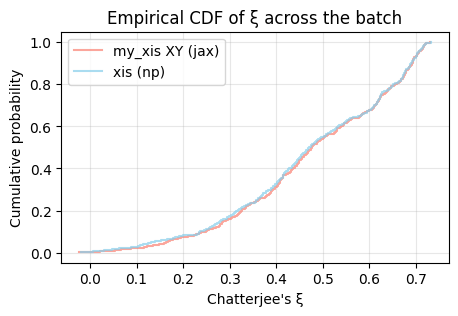

In [2]:
def example_sin_xi(n, noise_scale):

    def get_eps():
        return 1e-10 * np.random.randn(n)
    
    master_key = jax.random.PRNGKey(master_seed)
    keyX, keyY = jax.random.split(master_key)

    # Data 
    x = jnp.array(np.linspace(0, 2 * np.pi, n),dtype=jnp.double)
    y = jnp.array(np.sin(3 * x)  + np.random.normal(scale=noise_scale, size=n),dtype=jnp.double)

    my_xi_fn = build_corr_coeff_2D_ties(average=False)
    my_xi_fn_1D = build_corr_coeff_1D()
    rankdata_2D_ties = build_rankdata_2D_ties()
    key_distances = jax.random.PRNGKey(42)
    key_distances, subkey_distances = jax.random.split(key_distances) 
    get_similarities = build_get_similarities(key=subkey_distances, 
                                            sample_size=n, 
                                            similarity_fn=L2_distance,
                                            )
    sim_X, sim_Y = get_similarities(x,y)
    sim_X_ref, sim_Y_ref = get_similarities(x + get_eps(),y + get_eps())
    Rx = rankdata_2D_ties(sim_X,keyX)
    Ry = rankdata_2D_ties(sim_Y,keyY)

    my_xis = my_xi_fn((Rx,Ry))
    my_xi_xy = my_xi_fn_1D((rankdata_1D(x),rankdata_1D(y)))

    ### Ref: 
    xis = np.array([xi_correlation(sim_X_ref[b], sim_Y_ref[b]) for b in range(sim_X_ref.shape[0])])
    xi_xy = xi_correlation(x + get_eps(),y + get_eps())

    
    return x, y, xi_xy, my_xi_xy, xis, my_xis


x, y, xi_xy, my_xi_xy, xis, my_xis = example_sin_xi(n=1000, noise_scale=.2)

print(f'{my_xis[0].mean()=:.2f}')
# print(f'{my_xis[1].mean()=:.2f}')
print(f'{xis.mean()=:.2f}')
print(f'{xi_xy=:.2f}')
print(f'{my_xi_xy[0]=:.2f}')
print(f'{my_xis[0].max()=:.2f}')

import matplotlib.pyplot as plt

# Convert JAX arrays to NumPy
my_xis_XY = np.array(my_xis[0])
my_xis_YX = np.array(my_xis[1])

def ecdf(data):
    """Return the x (sorted) and y (cumulative probabilities) for ECDF."""
    x = np.sort(data)
    y = np.arange(1, len(data)+1) / len(data)
    return x, y

plt.figure(figsize=(5,3))


# ECDF for my_xis XY
x_jax, y_jax = ecdf(my_xis_XY)
plt.plot(x_jax, y_jax, drawstyle='steps-post', color='salmon', label='my_xis XY (jax)',alpha=0.7)

# ECDF for np xis
x_np, y_np = ecdf(xis)
plt.plot(x_np, y_np, drawstyle='steps-post', color='skyblue', label='xis (np)',alpha=0.7)

# # Optionally, ECDF for my_xis YX
# x_jax_yx, y_jax_yx = ecdf(my_xis_YX)
# plt.plot(x_jax_yx, y_jax_yx, drawstyle='steps-post', color='lightgreen', label='my_xis YX (jax)')

plt.xlabel("Chatterjee's ξ")
plt.ylabel("Cumulative probability")
plt.title("Empirical CDF of ξ across the batch")
plt.legend()
plt.grid(alpha=0.3)
plt.show()